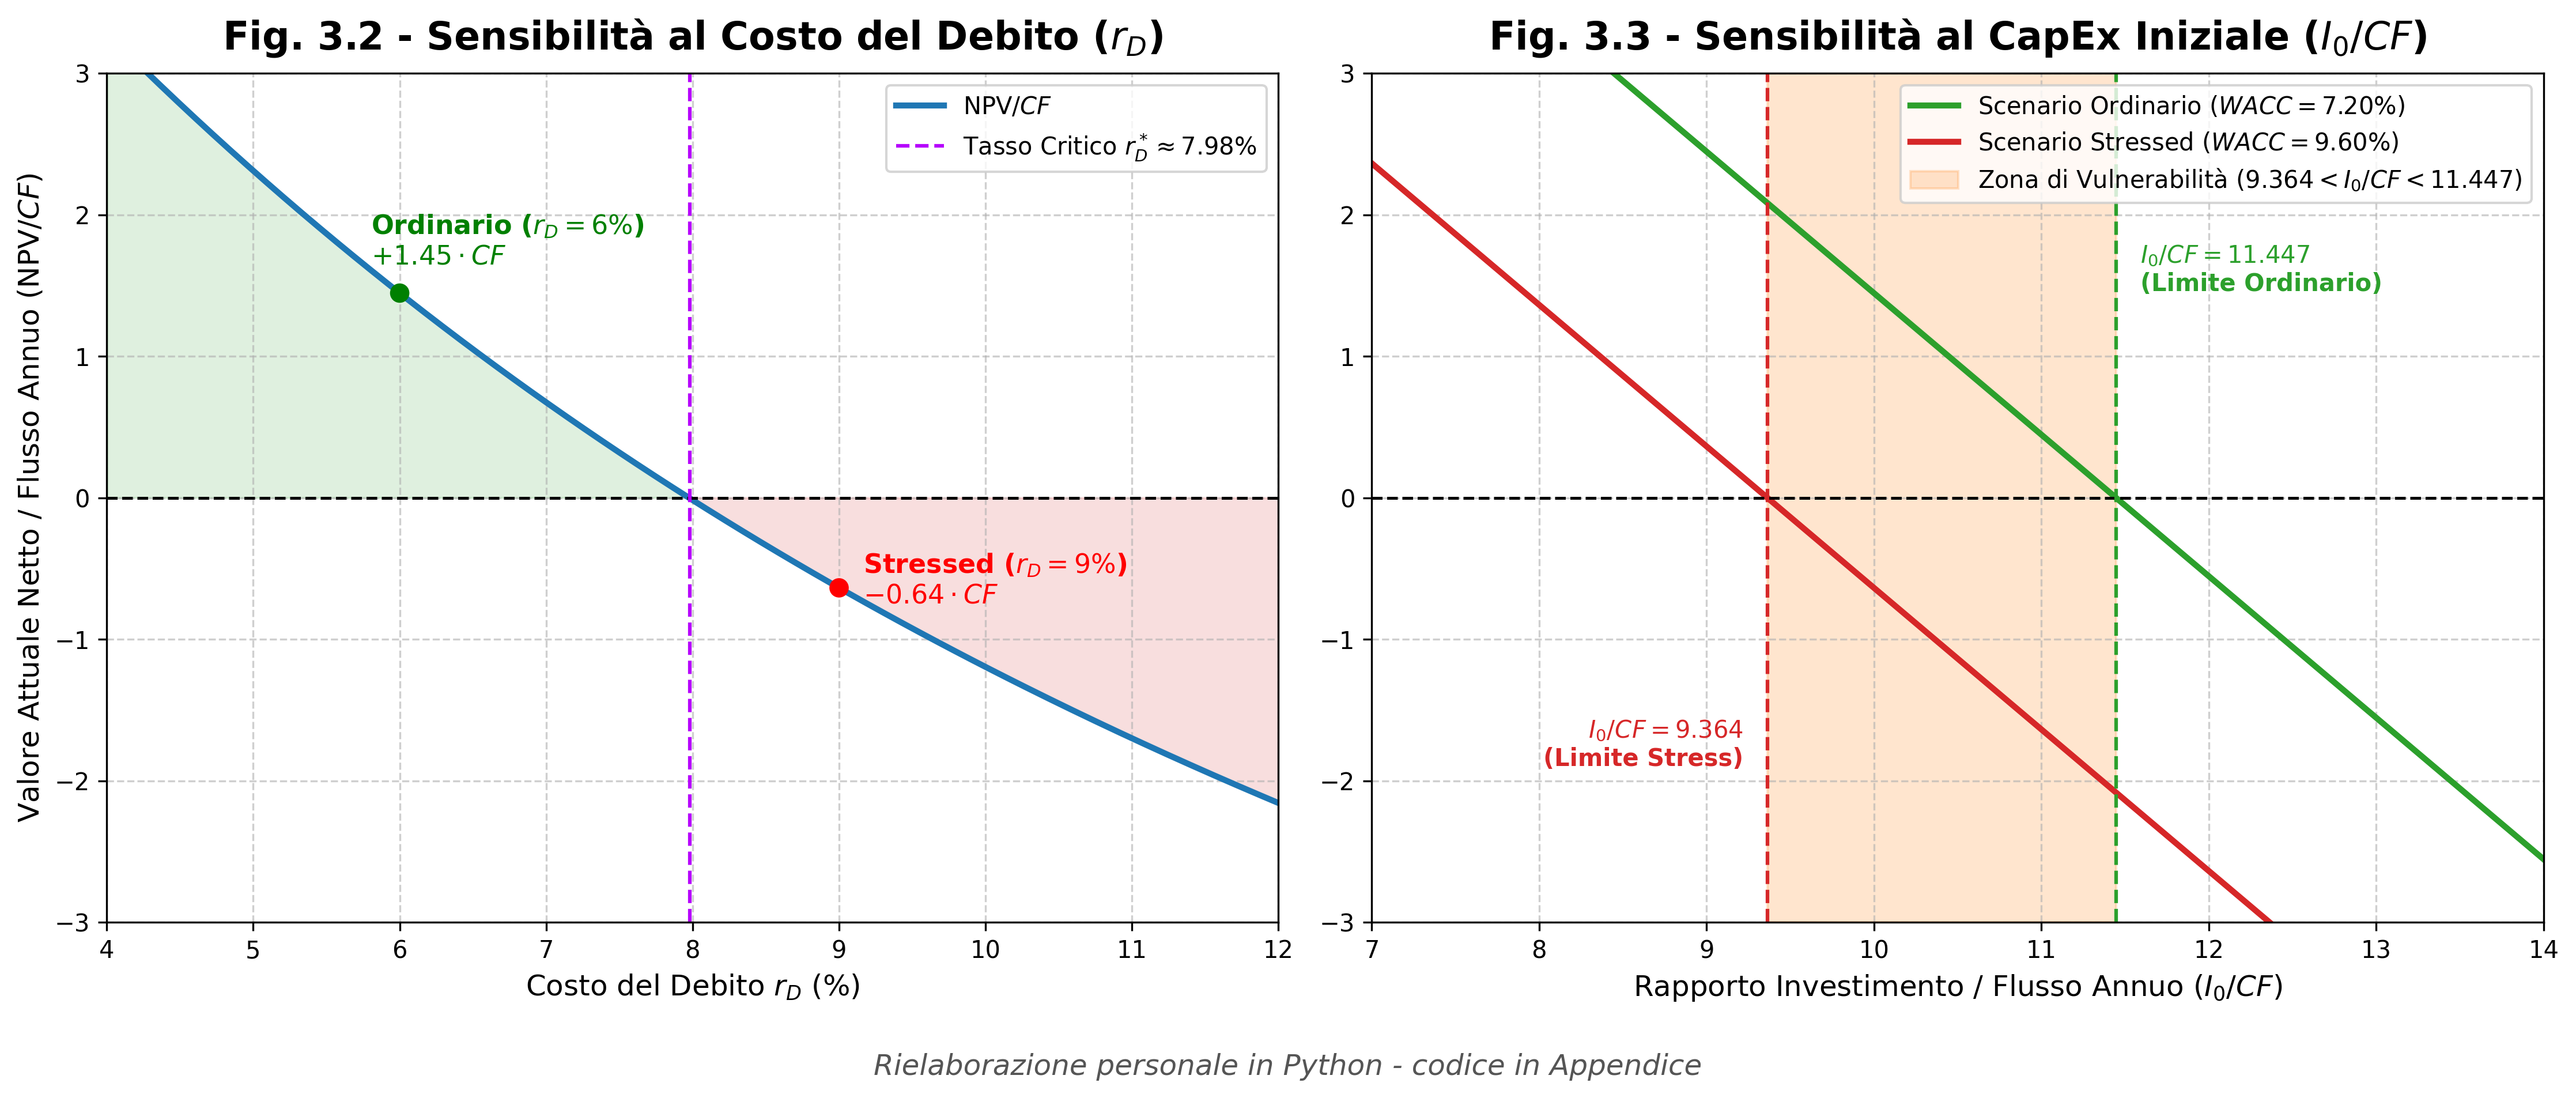

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# latex
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# data
y = 25
LTV = 0.70
E_V = 0.30
tc = 0.0  # Tonnage tax / no taxes

# punctual scenarios
rD_ord, rE_ord = 0.06, 0.10
WACC_ord = LTV * rD_ord + E_V * rE_ord
A_ord = (1 - (1 + WACC_ord) ** (-y)) / WACC_ord

rD_stress, rE_stress = 0.09, 0.11
WACC_stress = LTV * rD_stress + E_V * rE_stress
A_stress = (1 - (1 + WACC_stress) ** (-y)) / WACC_stress

# create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

#graph A
I0_CF_fixed = 10.0  # fixed investment value
r_D_vec = np.linspace(0.04, 0.12, 200)
r_E_vec = 0.10 + (1 / 3) * (r_D_vec - 0.06)  # linear relation r_E
WACC_vec = LTV * r_D_vec + E_V * r_E_vec
A_vec = (1 - (1 + WACC_vec) ** (-y)) / WACC_vec
VAN_norm_rD = A_vec - I0_CF_fixed

ax1.plot(
    r_D_vec * 100,
    VAN_norm_rD,
    color="#1f77b4",
    linewidth=2.5,
    label=r"$\text{NPV}/CF$",
)
ax1.axhline(0.0, color="black", linestyle="--", linewidth=1.2)

# highlighting areas
ax1.fill_between(
    r_D_vec * 100,
    VAN_norm_rD,
    0,
    where=(VAN_norm_rD >= 0),
    color="#2ca02c",
    alpha=0.15,
)
ax1.fill_between(
    r_D_vec * 100,
    VAN_norm_rD,
    0,
    where=(VAN_norm_rD < 0),
    color="#d62728",
    alpha=0.15,
)

# ord + stressed points
VAN_ord_fixed = A_ord - I0_CF_fixed
VAN_stress_fixed = A_stress - I0_CF_fixed

ax1.scatter(
    [6.0, 9.0],
    [VAN_ord_fixed, VAN_stress_fixed],
    color=["green", "red"],
    zorder=5,
    s=50,
)
ax1.annotate(
    f"Ordinario ($r_D=6\\%$)\n$+ {VAN_ord_fixed:.2f} \\cdot CF$",
    (6.0, VAN_ord_fixed),
    textcoords="offset points",
    xytext=(-12, 12),
    fontweight="bold",
    color="green",
    fontsize=11,
)
ax1.annotate(
    f"Stressed ($r_D=9\\%$)\n$- {-VAN_stress_fixed:.2f} \\cdot CF$",
    (9.0, VAN_stress_fixed),
    textcoords="offset points",
    xytext=(10, -6.5),
    fontweight="bold",
    color="red",
    fontsize=11,
)

# NPV = 0
idx_crit = np.argmin(np.abs(VAN_norm_rD))
rD_crit = r_D_vec[idx_crit] * 100
ax1.axvline(
    rD_crit,
    color="#b603fc",
    linestyle="--",
    linewidth=1.5,
    label=f"Tasso Critico $r_D^* \\approx {rD_crit:.2f}\\%$",
)

ax1.set_title(
    r"Fig. 3.2 - Sensibilità al Costo del Debito ($r_D$)", fontsize=16, pad=10, fontweight='bold'
)
ax1.set_xlabel(r"Costo del Debito $r_D$ (%)", fontsize=12)
ax1.set_ylabel(
    r"Valore Attuale Netto / Flusso Annuo ($\text{NPV}/CF$)", fontsize=12
)
ax1.set_xlim(4.0, 12.0)
ax1.set_ylim(-3.0, 3.0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc="upper right", frameon=True, facecolor="white")


# graph B
I0_CF_vec = np.linspace(7.0, 14.0, 200)

VAN_norm_ord_I0 = A_ord - I0_CF_vec
VAN_norm_stress_I0 = A_stress - I0_CF_vec

ax2.plot(
    I0_CF_vec,
    VAN_norm_ord_I0,
    color="#2ca02c",
    linewidth=2.5,
    label=r"Scenario Ordinario ($WACC = 7.20\%$)",
)
ax2.plot(
    I0_CF_vec,
    VAN_norm_stress_I0,
    color="#d62728",
    linewidth=2.5,
    linestyle="-",
    label=r"Scenario Stressed ($WACC = 9.60\%$)",
)
ax2.axhline(0.0, color="black", linestyle="--", linewidth=1.2)

# no convenience area
ax2.axvspan(
    A_stress,
    A_ord,
    color="#ff7f0e",
    alpha=0.2,
    label=r"Zona di Vulnerabilità ($9.364 < I_0/CF < 11.447$)",
)

# vertical lines
ax2.axvline(A_stress, color="#d62728", linestyle="--", linewidth=1.5)
ax2.axvline(A_ord, color="#2ca02c", linestyle="--", linewidth=1.5)

ax2.annotate(
    f"$I_0/CF = 9.364$\n(Limite Stress)",
    (A_stress, -2.2),
    textcoords="offset points",
    xytext=(-10, 18),
    fontsize=10,
    fontweight="bold",
    ha="right",
    color="#d62728",
)
ax2.annotate(
    f"$I_0/CF = 11.447$\n(Limite Ordinario)",
    (A_ord, 1.8),
    textcoords="offset points",
    xytext=(10, -20),
    fontsize=10,
    fontweight="bold",
    color="#2ca02c",
)

ax2.set_title(
    r"Fig. 3.3 - Sensibilità al CapEx Iniziale ($I_0/CF$)", fontsize=16, pad=10, fontweight='bold'
)
ax2.set_xlabel(
    r"Rapporto Investimento / Flusso Annuo ($I_0 / CF$)", fontsize=12
)

ax2.set_xlim(7.0, 14.0)
ax2.set_ylim(-3.0, 3.0)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="upper right", frameon=True, facecolor="white")

# subtitle
plt.figtext(0.5, -0.05, 'Rielaborazione personale in Python - codice in Appendice',
            ha='center', va='bottom', fontsize=12, color='#555555', fontstyle='italic')
plt.tight_layout()

# export pdf
plt.savefig("van_grafico.pdf", format="pdf", bbox_inches="tight")
plt.show()